In [1]:
import sys
from pymatgen.io.vasp.outputs import Outcar, Vasprun
import ase
import os
import numpy as np
from ase.io import read
from ase.visualize import view
import matplotlib.pyplot as plt
import pandas as pd


sys.path.append("Users/toghrulazizli/Desktop/montemoregroup/")

from energyCorrelationFunctions import *
from coordsFunctions import *
from VibrationFunctions import *
from databaseFunctions import *

In [2]:
readAtoms_H2= read('/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/H2_gas_vib/OUTCAR')
print(readAtoms_H2)

Atoms(symbols='H2', pbc=True, cell=[20.0, 20.1, 20.2], calculator=SinglePointDFTCalculator(...))


In [3]:
Vib=readVibFreq('/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/H2_gas_vib/')
print(Vib)

eVFreq_prop=Vib[0]
eVFreqOrdered = np.sort(eVFreq_prop)
eVFreqOrdered

(array([0.53413594, 0.03477929, 0.0342448 ]), array([7.25500e-06, 3.47670e-05, 6.88042e-04]))


/Users/toghrulazizli/Desktop/DFT/SettingUpCalcs/CO2_ethanol/databaseFunctions.py:17: FutureWarning: Vasp2 has been deprecated. Use the ase.calculators.vasp.Vasp class instead.
  vaspObj = Vasp2(directory=directory)


array([0.0342448 , 0.03477929, 0.53413594])

In [4]:
readAtoms_CO = read('/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/CO_gas_calc_vib/OUTCAR')
print(readAtoms_CO)

Atoms(symbols='CO', pbc=True, cell=[20.0, 20.1, 20.2], calculator=SinglePointDFTCalculator(...))


In [5]:
Vib=readVibFreq('/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/CO_gas_calc_vib/')
print(Vib)

eVFreq_prop=Vib[0]
eVFreqOrdered = np.sort(eVFreq_prop)
eVFreqOrdered

(array([0.26326274, 0.00464573, 0.00317635]), array([6.635800e-05, 3.305966e-03, 3.329339e-03]))


array([0.00317635, 0.00464573, 0.26326274])

In [8]:
readAtoms_CO2 = read('/Users/toghrulazizli/Desktop/DFT/Calculations/Gas_phase/CO2_Vib/OUTCAR')
print(readAtoms_CO2)

Atoms(symbols='CO2', pbc=True, cell=[20.0, 20.1, 20.2], calculator=SinglePointDFTCalculator(...))


In [9]:
Vib=readVibFreq('/Users/toghrulazizli/Desktop/DFT/Calculations/Gas_phase/CO2_Vib')
print(Vib)

eVFreq_prop=Vib[0]
eVFreqOrdered = np.sort(eVFreq_prop)
eVFreqOrdered

(array([2.94224922e-01, 1.63832331e-01, 7.86980390e-02, 7.66231040e-02,
       4.70309800e-03, 1.42230000e-04]), array([4.866000e-05, 3.084390e-04, 8.471855e-03]))


/Users/toghrulazizli/Desktop/DFT/SettingUpCalcs/CO2_ethanol/databaseFunctions.py:17: FutureWarning: Vasp2 has been deprecated. Use the ase.calculators.vasp.Vasp class instead.
  vaspObj = Vasp2(directory=directory)


array([1.42230000e-04, 4.70309800e-03, 7.66231040e-02, 7.86980390e-02,
       1.63832331e-01, 2.94224922e-01])

In [65]:
#Ethylene reading atoms

readAtoms_H2O = read('/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/H2O_gas_vib/OUTCAR')
print(readAtoms_H2O)
#view(readAtoms_H2O)

Atoms(symbols='OH2', pbc=True, cell=[20.0, 20.1, 20.2], calculator=SinglePointDFTCalculator(...))


In [66]:
Vib=readVibFreq('/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/H2O_gas_vib/')
print(Vib)

eVFreq=Vib[0]
eVFreqOrdered = np.sort(eVFreq)
eVFreqOrdered

(array([0.47463492, 0.46061038, 0.19641946, 0.02271387, 0.01075526]), array([0.00082614, 0.00449367, 0.00570241, 0.01375679]))


/Users/toghrulazizli/Desktop/DFT/SettingUpCalcs/CO2_ethanol/databaseFunctions.py:17: FutureWarning: Vasp2 has been deprecated. Use the ase.calculators.vasp.Vasp class instead.
  vaspObj = Vasp2(directory=directory)


array([0.01075526, 0.02271387, 0.19641946, 0.46061038, 0.47463492])

In [67]:
def deltaMuH2(temp, pressure):
    eVFreqOrdered= np.array([0.0342448 , 0.03477929, 0.53413594])
    
    MuH2GasPhaseEng= -6.75930865
  
    
    thermo = IdealGasThermo(vib_energies=eVFreqOrdered,
                      potentialenergy=0,
                      atoms=readAtoms_H2,
                      geometry='linear',
                      symmetrynumber=2, 
                      spin=0)
    MuH2Abs=[]
    if isinstance(pressure, np.ndarray):
        for i in pressure:
            freeEnCorr = thermo.get_gibbs_energy(temp, i, verbose = False)
            MuH2Abs.append(MuH2GasPhaseEng+freeEnCorr)
        return np.array(MuH2Abs)
            
    elif isinstance(temp, np.ndarray):
        for i in temp:
            freeEnCorr = thermo.get_gibbs_energy(i, pressure, verbose = False)
            MuH2Abs.append(MuH2GasPhaseEng+freeEnCorr)
        return np.array(MuH2Abs)
    
    else:
        freeEnCorr = thermo.get_gibbs_energy(temp, pressure, verbose = False)
        return MuH2GasPhaseEng+freeEnCorr
  

In [68]:
def deltaMuCO(temp, pressure):
    eVFreqOrdered= np.array([0.00317635, 0.00464573, 0.26326274])
    
    MuCOGasPhaseEng= -14.79618318
  
    
    thermo = IdealGasThermo(vib_energies=eVFreqOrdered,
                      potentialenergy=0,
                      atoms=readAtoms_CO,
                      geometry='linear',
                      symmetrynumber=1, 
                      spin=0)
    MuCOAbs=[]
    if isinstance(pressure, np.ndarray):
        for i in pressure:
            freeEnCorr = thermo.get_gibbs_energy(temp, i, verbose = False)
            MuCOAbs.append(MuCOGasPhaseEng+freeEnCorr)
        return np.array(MuCOAbs)
            
    elif isinstance(temp, np.ndarray):
        for i in temp:
            freeEnCorr = thermo.get_gibbs_energy(i, pressure, verbose = False)
            MuCOAbs.append(MuCOGasPhaseEng+freeEnCorr)
        return np.array(MuCOAbs)
    else:
        freeEnCorr = thermo.get_gibbs_energy(temp, pressure, verbose = False)
        return MuCOGasPhaseEng+freeEnCorr
            

In [69]:
def deltaMuCO2(temp, pressure):
    eVFreqOrdered= np.array([1.42230000e-04, 4.70309800e-03, 7.66231040e-02, 7.86980390e-02,
       1.63832331e-01, 2.94224922e-01])
    
    MuCO2GasPhaseEng= -22.98687490
  
    
    thermo = IdealGasThermo(vib_energies=eVFreqOrdered,
                      potentialenergy=0,
                      atoms=readAtoms_CO2,
                      geometry='linear',
                      symmetrynumber=2, 
                      spin=0)
    MuCO2Abs=[]
    if isinstance(pressure, np.ndarray):
        for i in pressure:
            freeEnCorr = thermo.get_gibbs_energy(temp, i, verbose = False)
            MuCO2Abs.append(MuCO2GasPhaseEng+freeEnCorr)
        return np.array(MuCO2Abs)
            
    elif isinstance(temp, np.ndarray):
        for i in temp:
            freeEnCorr = thermo.get_gibbs_energy(i, pressure, verbose = False)
            MuCO2Abs.append(MuCO2GasPhaseEng+freeEnCorr)
        return np.array(MuCO2Abs)
    else:
        freeEnCorr = thermo.get_gibbs_energy(temp, pressure, verbose = False)
        return MuCO2GasPhaseEng+freeEnCorr
            

In [70]:
cutoff = 4/1000
def getHarmonic(realFreq, imagFreq, cutoff = cutoff, gasPhase = False, verbose = True):
    ### TODO: Add in gas-phase here too
    if gasPhase == False:
        numAtomsMove = int((len(realFreq)+len(imagFreq))/3)
        eVFreqForHarm = prepFreqForHarmonic(realFreq,numAtomsMove,cutoff = cutoff)
        harmonic = HarmonicThermo(eVFreqForHarm)
        return harmonic

#a code that takes a directory and cut off, calculates the harmonic
def calc_harmonic_from_VibCalc(dirName,cutoff,verbose = True):
    Vib_freqs=readVibFreq(dirName)
    realFreq=Vib_freqs[0]
    imagFreq=Vib_freqs[1]
    if verbose: 
        print(realFreq,imagFreq)
    
    harmonic=getHarmonic(realFreq, imagFreq, cutoff = cutoff, gasPhase = False, verbose = False)
    return harmonic

def getFreeEnergy(temp, harmonic, verbose = True):
    if isinstance(temp,np.ndarray):
        freeEnergy = []
        for i in temp:
            freeEnergy += [harmonic.get_helmholtz_energy(i,verbose = verbose)] #Includes ZPE
        return np.array(freeEnergy)
    else:
        freeEnergy = harmonic.get_helmholtz_energy(temp,verbose = verbose)
        return freeEnergy

In [71]:
def deltaMuH2O(temp, pressure):
    eVFreqOrdered= np.array([0.01075526, 0.02271387, 0.19641946, 0.46061038, 0.47463492])
    
    MuH2OGasPhaseEng= -14.22024438
  
    
    thermo = IdealGasThermo(vib_energies=eVFreqOrdered,
                      potentialenergy=0,
                      atoms=readAtoms_H2O,
                      geometry='nonlinear',
                      symmetrynumber=2, 
                      spin=0)
    MuH2OAbs=[]
    if isinstance(pressure, np.ndarray):
        for i in pressure:
            freeEnCorr = thermo.get_gibbs_energy(temp, i, verbose = False)
            MuH2OAbs.append(MuH2OGasPhaseEng+freeEnCorr)
        return np.array(MuH2OAbs)
            
    elif isinstance(temp, np.ndarray):
        for i in temp:
            freeEnCorr = thermo.get_gibbs_energy(i, pressure, verbose = False)
            MuH2OAbs.append(MuH2OGasPhaseEng+freeEnCorr)
        return np.array(MuH2OAbs)
    else:
        freeEnCorr = thermo.get_gibbs_energy(temp, pressure, verbose = False)
        return MuH2OGasPhaseEng+freeEnCorr
            

In [72]:
P_H2 = 101325
P_CO = 101325
P_CO2 = 101325
T = 298.15   

In [73]:
mu_H2 = deltaMuH2(T, P_H2)
mu_CO = deltaMuCO(T, P_CO)
mu_CO2 = deltaMuCO2(T, P_CO2)
P_H2O = 3170 #Pa vapor pressure at 25C
mu_H2O = deltaMuH2O(T, P_H2O)
print("Mu H2 at T =", T, "K and P =", P_H2, "Pa is:", mu_H2, "eV")
print("Mu CO at T =", T, "K and P =", P_CO, "Pa is:", mu_CO, "eV")
print("Mu CO2 at T =", T, "K and P =", P_CO2, "Pa is:", mu_CO2, "eV")
print("Mu H2O at T =", T, "K and P =", P_H2O, "Pa is:", mu_H2O, "eV")

Mu H2 at T = 298.15 K and P = 101325 Pa is: -6.805719314942781 eV
Mu CO at T = 298.15 K and P = 101325 Pa is: -15.185624424616792 eV
Mu CO2 at T = 298.15 K and P = 101325 Pa is: -23.244517495371678 eV
Mu H2O at T = 298.15 K and P = 3170 Pa is: -14.224578688304168 eV


In [74]:
import os
import pandas as pd
import ase.io

calculation_dir = '/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/'
os.chdir(calculation_dir)
parentDir = "Vib_Calcs_new"

data = []   # this will become the DataFrame

for dirName in sorted(os.listdir(parentDir)):
    if dirName == '.DS_Store':
        continue

    dirName_calc = dirName.replace("_vib", "")

    harmonic = calc_harmonic_from_VibCalc(
        parentDir + "/" + dirName,
        cutoff=4/1000,
        verbose=False
    )

    correction = getFreeEnergy(T, harmonic, verbose=False)

    atoms = ase.io.read(calculation_dir + dirName_calc + '/OUTCAR')
    potential_energy = atoms.get_potential_energy()

    freeEnergy = potential_energy + correction

    # store everything
    data.append({
        "Structure": dirName_calc,
        "E_DFT (eV)": potential_energy,
        "G_vib_correction (eV)": correction,
        "G_total (eV)": freeEnergy,
        "Temperature (K)": T
    })

# build DataFrame
df = pd.DataFrame(data)

# set Structure as index FIRST
df = df.set_index("Structure")

# now sort by free energy WITHOUT resetting index
df = df.sort_values("G_total (eV)")

display(df)


,E_DFT (eV),G_vib_correction (eV),G_total (eV),Temperature (K)
Structure,,,,
COCHO_4OYPdCu_5,-453.511523,0.775676,-452.735847,298.15
COCOH_4OYCu_3,-452.234058,0.841437,-451.392621,298.15
CO_CO_4OYPdCu100_4,-450.651955,0.366264,-450.285691,298.15
CO_CO_4OYPdCu100_5,-450.549729,0.433846,-450.115883,298.15
CO_CO_4OYCu100_9,-449.449087,0.416491,-449.032596,298.15
COOH_4OYPdCu100_15,-445.334283,0.707665,-444.626618,298.15
CO2_4OYPdCu100_3,-442.343327,0.347273,-441.996054,298.15
CHO_4OYPdCu100_5,-437.649756,0.579582,-437.070174,298.15
CO_4OYPdCu100_2,-434.707489,0.275827,-434.431662,298.15


In [75]:
df.loc["4OYPdCu100_1_4","G_total (eV)"]
df.loc["HO_3OYPdCu_1","G_total (eV)"]
df.loc["H2O_3OYPdCu_1","G_total (eV)"]
df.loc["4OYPdCu100_0O_1","G_total (eV)"]

-411.4031139108831

In [76]:
df.loc["COCHO_4OYPdCu_5","G_total (eV)"]

-452.73584708725156

### The Free energy of COCHO on O4YPdCu

In [77]:
E_COCHO_O4YPdCu = df.loc["COCHO_4OYPdCu_5","G_total (eV)"] - df.loc["4OYPdCu100_1_4","G_total (eV)"] - (mu_H2/2) - (2*mu_CO)
print("The Free energy of COCHO on O4YPdCu at T =", T, "K is:", E_COCHO_O4YPdCu, "eV")

The Free energy of COCHO on O4YPdCu at T = 298.15 K is: -0.3666088487457877 eV


### The Free energy of 2CO on O4YPdCu

In [78]:
E_2CO_O4YPdCu = df.loc["CO_CO_4OYPdCu100_4","G_total (eV)"] - df.loc["4OYPdCu100_1_4","G_total (eV)"] - (2*mu_CO)
print("The Free energy of 2CO on O4YPdCu at T =", T, "K is:", E_2CO_O4YPdCu, "eV")

The Free energy of 2CO on O4YPdCu at T = 298.15 K is: -1.3193123565143559 eV


### The Free energy change of C-C coupling on O4YPdCu

In [79]:
print(E_COCHO_O4YPdCu - E_2CO_O4YPdCu)

0.9527035077685682


### The Free energy of COCHO on O4YCu

In [80]:
E_COCOH_O4YCu = df.loc["COCOH_4OYCu_3","G_total (eV)"] - df.loc["4OYCu100","G_total (eV)"] - (mu_H2/2) - (2*mu_CO)
print("The Free energy of COCOH on O4YCu at T =", T, "K is:", E_COCOH_O4YCu, "eV")

The Free energy of COCOH on O4YCu at T = 298.15 K is: -0.2665185729967483 eV


### The Free energy of 2CO on O4YCu

In [81]:
E_2CO_O4YCu = df.loc["CO_CO_4OYCu100_9","G_total (eV)"] - df.loc["4OYCu100","G_total (eV)"] - (2*mu_CO)
print("The Free energy of 2CO on O4YCu at T =", T, "K is:", E_2CO_O4YCu, "eV")

The Free energy of 2CO on O4YCu at T = 298.15 K is: -1.3093536891173834 eV


### The Free energy change of C-C coupling on O4YCu

In [82]:
print(E_COCOH_O4YCu - E_2CO_O4YCu)

1.042835116120635


### The Free energy of COCOH on Cu100

In [83]:
E_COCOH_Cu = df.loc["COCOH_Cu100","G_total (eV)"] - (-381.84276304) - (mu_H2/2) - (2*mu_CO)
print("The Free energy of COCOH on Cu100 at T =", T, "K is:", E_COCOH_Cu, "eV")

The Free energy of COCOH on Cu100 at T = 298.15 K is: -0.2631225404271653 eV


### The Free energy of 2CO on Cu100

In [84]:
E_2CO_Cu = df.loc["CO_CO_Cu100_8","G_total (eV)"] - (-381.84276304) - (2*mu_CO)
print("The Free energy of 2CO on Cu100 at T =", T, "K is:", E_2CO_Cu, "eV")

The Free energy of 2CO on Cu100 at T = 298.15 K is: -1.3233155584579457 eV


### The Free energy of C-C coupling on Cu100

In [85]:
print(E_COCOH_Cu - E_2CO_Cu)

1.0601930180307804


### H ads Free energy on O4YPdCu

In [86]:
E_H_O4YPdCu_1 = -421.9133675374182 - (-418.5951297318008) - (mu_H2/2)
print("The Free energy of H ads on O4YPdCu at T =", T, "K is:", E_H_O4YPdCu_1, "eV")

The Free energy of H ads on O4YPdCu at T = 298.15 K is: 0.0846218518539903 eV


In [87]:
E_H_O4YPdCu_4 = -422.12378479342715 - (-418.5951297318008) - (mu_H2/2)
print("The Free energy of H ads on O4YPdCu at T =", T, "K is:", E_H_O4YPdCu_4, "eV")

The Free energy of H ads on O4YPdCu at T = 298.15 K is: -0.12579540415496204 eV


### H ads Free energy on Cu100

In [88]:
E_H_Cu = -385.38501909132816 - (-381.84276304) - (mu_H2/2)
print("The Free energy of H ads on Cu100 at T =", T, "K is:", E_H_Cu, "eV")

The Free energy of H ads on Cu100 at T = 298.15 K is: -0.13939639385674774 eV


# CO2 COOH CO and CHO

In [94]:
E_CO2_O4YPdCu = df.loc["CO2_4OYPdCu100_3","G_total (eV)"] - df.loc["4OYPdCu100_1_4","G_total (eV)"] - mu_CO2
E_COOH_O4YPdCu = df.loc["COOH_4OYPdCu100_15","G_total (eV)"] - df.loc["4OYPdCu100_1_4","G_total (eV)"] - (mu_H2/2) - mu_CO2
E_CO = df.loc["CO_4OYPdCu100_2","G_total (eV)"] + mu_H2O - df.loc["4OYPdCu100_1_4","G_total (eV)"] - mu_CO2 - mu_H2
E_CHO = df.loc["CHO_4OYPdCu100_5","G_total (eV)"] + mu_H2O - df.loc["4OYPdCu100_1_4","G_total (eV)"] - (mu_H2*3/2) - mu_CO2

In [95]:
E_1C = [E_CO2_O4YPdCu, E_COOH_O4YPdCu, E_CO, E_CHO]
print(E_1C)

[-0.15640709286877907, 0.6158889959300247, -0.010874484493001546, 0.7534735448235459]


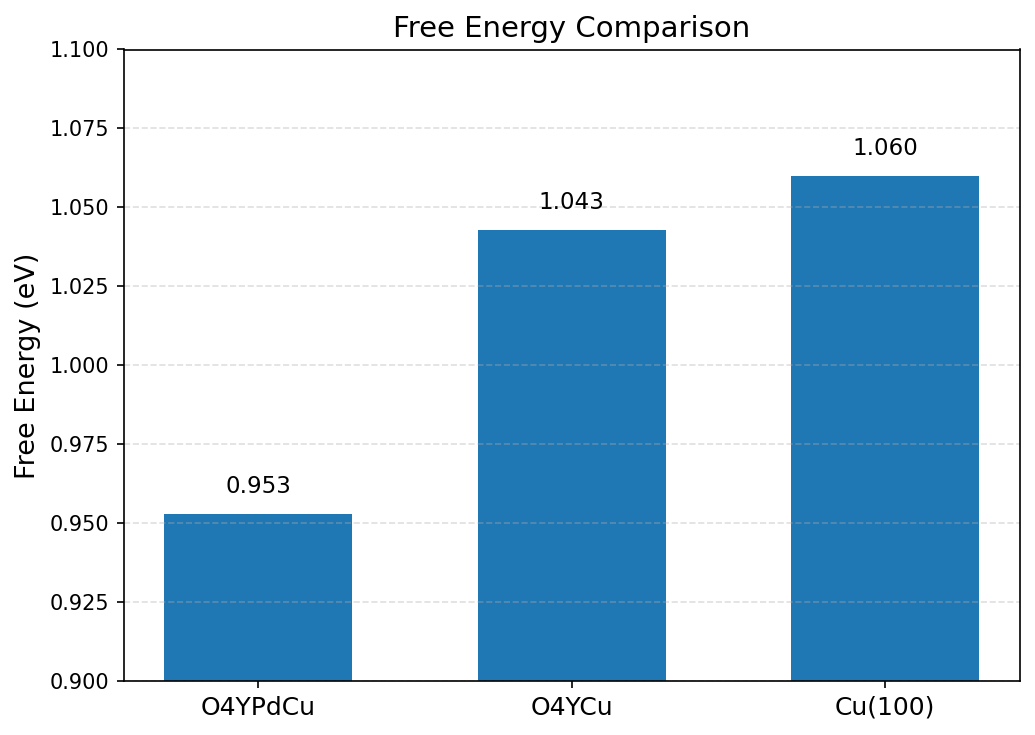

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Original data
labels = ['O4YPdCu', 'O4YCu', 'Cu(100)']
free_energies_raw = [E_COCHO_O4YPdCu - E_2CO_O4YPdCu, E_COCOH_O4YCu - E_2CO_O4YCu, E_COCOH_Cu - E_2CO_Cu]

# Round to 0.001 eV
free_energies = np.round(free_energies_raw, 3)

# Positions
x = np.arange(len(labels))

# Create figure
plt.figure(figsize=(7,5), dpi=150)

# Bar plot
bars = plt.bar(x, free_energies, width=0.6)

# Add values on top of bars
for bar, val in zip(bars, free_energies):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 0.005,
             f"{val:.3f}",
             ha='center',
             va='bottom',
             fontsize=11)

# Labels and title
plt.xticks(x, labels, fontsize=12)
plt.ylabel("Free Energy (eV)", fontsize=13)
plt.title("Free Energy Comparison", fontsize=14)

# Nice layout
plt.ylim(0.9, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("free_energy_barplot.png", dpi=300)
plt.show()


## O popping up as a water

In [75]:
G_surf = df.loc["4OYPdCu100_1_4","G_total (eV)"]
G_OH = df.loc["HO_3OYPdCu_1","G_total (eV)"]
G_O2H = df.loc["H2O_3OYPdCu_1","G_total (eV)"]
G_0H_surf = df.loc["4OYPdCu100_0O_1","G_total (eV)"]

In [76]:
print(mu_H2O)

-14.224578688304168


In [77]:

# Surface states and energies
State = ["YO$_4$", "YO$_3$-OH", "YO$_3$-OH$_2$", "YO$_3$+H$_2$O"]
Energies = [0, G_OH - G_surf - (mu_H2/2), G_O2H - G_surf - mu_H2, G_0H_surf - G_surf + mu_H2O- mu_H2]



In [78]:
print(Energies)

[0, 0.39017845316166166, -0.7153670219646067, -0.22684355244371268]


In [79]:
Energies_0_49V = [0, G_OH - G_surf - (mu_H2/2) - 0.49, G_O2H - G_surf - mu_H2 - (0.49*2), G_0H_surf - G_surf + mu_H2O - mu_H2 - (0.49*2)]

In [80]:
print(Energies_0_49V)

[0, -0.09982154683833833, -1.6953670219646066, -1.2068435524437127]


In [81]:
Energies_1_0V = [0, G_OH - G_surf - (mu_H2/2) - 1, G_O2H - G_surf - mu_H2 - (1*2), G_0H_surf - G_surf + mu_H2O - mu_H2 - (1*2)]

In [82]:
print(Energies_1_0V)

[0, -0.6098215468383383, -2.7153670219646067, -2.2268435524437127]
